# 4.1 Neural Networks

A linear regression is a single, fully connected neuron.

![Single Neuron](../img/TLU.png)

Figure: a threshold logic unit (after A. Géron, *Hands-On Machine Learning*, 2019).

A single artificial neuron computes a weighted sum of its inputs plus one bias term, then applies an activation function:

$y = f( \sum_{i=1}^3  w_i x_i + b)$,

where $y$ is the output, $w_i$ are the weights, $b$ is the bias of the neuron (one per neuron, not one per input), and $f$ is an activation function (e.g., sigmoid, ReLU, etc).

The choice of $f$ names the unit. With a step activation that fires when the weighted sum exceeds a threshold, the neuron is a **Threshold Logic Unit** (TLU): it outputs a hard positive/negative decision. With the sigmoid activation, the same neuron computes a logistic regression and outputs a probability instead.

A perceptron is a single layer of TLUs, with each TLU connected to all the inputs.

**Logistic regression is just a one-layer neural network classifier.**

In this notebook we build our first neural network in PyTorch and train it on a 4-class classification problem. The workflow has five steps that repeat in every deep-learning project:

1. Prepare the **dataset**.
2. Design the **model**.
3. Choose the **loss function**.
4. Choose the **optimizer**.
5. Write the **training loop**.

🖥️ [**Lecture slides — Session 21 (Wed Nov 18)**](slides/2026/lec21_neuron_to_network.html)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

# Device-agnostic setup: use a GPU if one is available.
device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available()
                      else "cpu")
print("Using device:", device)

torch.manual_seed(42)
np.random.seed(42)

Using device: mps


## 1. Dataset in PyTorch

We reuse the seismic-source dataset from Chapter 3: 62 physical features (waveform, envelope, and spectral statistics) extracted from seismograms of four source types recorded in the Pacific Northwest: **earthquake**, **explosion**, **noise**, and **surface event**. In Chapter 3 you classified these events with classical machine learning (random forests reached roughly 80-90% accuracy). Here we train a neural network on the same problem, so you can compare the two approaches directly.

The data lives on Zenodo as four CSV files, one per class, with 1,000 events each. We download them with `pooch`, which caches the files locally.

### 1.1 Load and label the data

In [2]:
import pooch

base = "https://zenodo.org/api/records/14025693/files"
classes = ["earthquakes", "explosion", "noise", "surface"]

frames = []
for c in classes:
    fname = f"1000_{c}_physical_features.csv"
    path = pooch.retrieve(f"{base}/{fname}/content", known_hash=None, fname=fname)
    frames.append(pd.read_csv(path))

df = pd.concat(frames, ignore_index=True)
print(df.shape)
print(df["source"].value_counts())

(4000, 65)
source
earthquake       1000
explosion        1000
noise            1000
surface event    1000
Name: count, dtype: int64


### 1.2 Clean the feature table

The table has 65 columns. Three are not features: `Unnamed: 0` (a leftover row index), `serial_no` (an event identifier), and `source` (the class name, which becomes our label). We map the four class names to integers 0-3, which is the label format that PyTorch's classification loss expects.

We also check for missing and infinite values. One feature column, `Gamma`, is empty (all NaN) in this dataset, so we drop the column rather than drop every row or invent values by imputation. After cleaning, no NaN or inf remain and we keep 61 numeric features.

In [3]:
class_names = ["earthquake", "explosion", "noise", "surface event"]
labels = df["source"].map({name: i for i, name in enumerate(class_names)}).to_numpy()

features = df.drop(columns=["Unnamed: 0", "serial_no", "source"])

# Columns that are entirely NaN carry no information: drop them.
all_nan = features.columns[features.isna().all()]
print("Dropping all-NaN columns:", list(all_nan))
features = features.drop(columns=all_nan)

print("Remaining NaN:", int(features.isna().sum().sum()),
      "- inf:", int(np.isinf(features.to_numpy()).sum()))

X = features.to_numpy(dtype=np.float32)
n_features = X.shape[1]
print("Feature matrix:", X.shape, "- labels:", labels.shape)

Dropping all-NaN columns: ['Gamma']
Remaining NaN: 0 - inf: 0
Feature matrix: (4000, 61) - labels: (4000,)


### 1.3 Split, then scale

We split the data three ways: **train** (60%) to fit the weights, **validation** (20%) to monitor generalization during training, and **test** (20%) held out for the final evaluation. The split is stratified so each subset keeps the same class balance.

Neural networks train poorly when input features span very different ranges, so we standardize each feature to zero mean and unit variance. The scaler is **fit on the training set only** and then applied to the validation and test sets. Fitting it on all the data would leak information from the held-out sets into training.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 60% train, 20% validation, 20% test, stratified by class.
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, labels, test_size=0.4, random_state=42, stratify=labels)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, random_state=42, stratify=y_tmp)

scaler = StandardScaler().fit(X_train)          # fit on train only
X_train = scaler.transform(X_train).astype(np.float32)
X_val = scaler.transform(X_val).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

print("train:", X_train.shape, " val:", X_val.shape, " test:", X_test.shape)

train: (2400, 61)  val: (800, 61)  test: (800, 61)


### 1.4 Create a custom Dataset class

PyTorch provides the `Dataset` class that you can use to wrap your arrays. You need to implement the `__len__` and `__getitem__` methods. The class also converts the NumPy arrays into `tensors`: float32 for the features, int64 (`long`) for the class labels.

In [5]:
from torch.utils.data import Dataset

class SeismicFeatures(Dataset):
    def __init__(self, data, labels):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        return self.data[index], self.labels[index]

train_dataset = SeismicFeatures(X_train, y_train)
val_dataset = SeismicFeatures(X_val, y_val)
test_dataset = SeismicFeatures(X_test, y_test)

sample_x, sample_y = train_dataset[0]
print("one sample:", sample_x.shape, sample_x.dtype, "- label:", sample_y.item())

one sample: torch.Size([61]) torch.float32 - label: 1


### 1.5 Create a DataLoader

Once you have a dataset, a `DataLoader` handles batching and shuffling. We shuffle the training set at every epoch so batches are different each time; validation and test sets do not need shuffling.

In [6]:
from torch.utils.data import DataLoader

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

for batch_data, batch_labels in train_loader:
    print("batch data:", batch_data.shape)
    print("batch labels:", batch_labels.shape)
    break

batch data: torch.Size([128, 61])
batch labels: torch.Size([128])


## 2. Design the Model

Our first neural network has a single hidden layer: a linear map from the 61 input features to 32 hidden units, a ReLU activation, and a linear map from the hidden units to 4 output scores, one per class.

The raw outputs are called **logits**. We do not apply softmax inside the model: PyTorch's cross-entropy loss (Section 3) applies it internally, which is both numerically safer and the standard practice.

A model is a subclass of `nn.Module`. The `__init__` method declares the layers; the `forward` method defines how data flows through them.

In [7]:
class NN1(nn.Module):

    def __init__(self, n_features, n_hidden, n_classes):
        # super() makes NN1 inherit the machinery of nn.Module
        super().__init__()
        self.hidden = nn.Linear(n_features, n_hidden)  # z1 = W1 x + b1
        self.activation = nn.ReLU()                    # a1 = max(0, z1)
        self.output = nn.Linear(n_hidden, n_classes)   # logits = W2 a1 + b2

    def forward(self, x):
        x = self.activation(self.hidden(x))
        return self.output(x)   # raw logits; softmax lives in the loss

We create a model of the class `NN1` and move it to the compute device with `.to(device)`. All tensors we feed it must live on the same device.

In [8]:
model = NN1(n_features=n_features, n_hidden=32, n_classes=4).to(device)
print(model)

n_params = sum(p.numel() for p in model.parameters())
print(f"trainable parameters: {n_params}")

NN1(
  (hidden): Linear(in_features=61, out_features=32, bias=True)
  (activation): ReLU()
  (output): Linear(in_features=32, out_features=4, bias=True)
)
trainable parameters: 2116


## 3. Loss Function

For binary classification, we defined the logistic or *sigmoid* function,

$\hat{y} = \frac{1}{1 + e^{-z}}$,

as the probability function of a binary classifier.

The log loss function to minimize is:

$\mathcal{L} =  - (y \log \hat{y} + (1 - y) \log (1 - \hat{y}))$ with $\hat{y} = \frac{1}{1 + e^{-z}}$.

We want to find the weights $w$ and biases $b$ such that $P(Y = y)$ is maximum, which is equivalent to minimizing the loss $\mathcal{L}$.

For a multi-class classification with $K$ classes, the sigmoid function is extended to a *softmax function*,

$P(Y = k) = \frac{\exp(w_k x + b_k)}{\sum_{j = 1}^K \exp(w_j x + b_j)}$.

Once we have found the values of $w_k$ and $b_k$ for $k = 1, \cdots, K$, we can compute the values of $P(Y = k)$. We then look for the value of $k$ for which $P(Y = k)$ is maximal and classify the sample as class $k$. Here $K = 4$.

Similarly, we define the loss with $K$ classes:

$\mathcal{L} = - \sum_{k = 1}^K y_k \log \frac{\exp(w_k x + b_k)}{\sum_{j = 1}^K \exp(w_j x + b_j)}$,

where $y_k = 1$ if the true label of sample $x$ is $k$, and $y_k = 0$ otherwise.

This is called the _cross-entropy loss_. In PyTorch, `nn.CrossEntropyLoss` combines the softmax and the log loss in one function, which is why the model outputs raw logits.

In [9]:
criterion = nn.CrossEntropyLoss()
criterion

CrossEntropyLoss()

## 4. Optimization

*Gradient descent* uses the entire data set to compute the gradient and step toward the minimum of the loss. Effectively, the batch size is the entire data set.

*Mini-batch gradient descent* uses batches of data to compute the gradient, updates the weights, and moves on to the next batch. The loss is averaged over the samples in the batch before the gradient is computed.

*Stochastic gradient descent* (SGD) uses one sample at a time. Effectively, the batch size is 1.

We use mini-batches with the **Adam** optimizer, a variant of gradient descent that adapts the step size for each parameter from running averages of the gradient and its square. Adam usually converges faster than plain SGD and is the default choice for a first attempt.

Parameters to choose are:
* the optimizer (SGD, Adam, or others),
* the learning rate (the scale of the step taken along the gradient).

In [10]:
learning_rate = 1e-3
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

## 5. Training

Parameters to choose are:
* **batch size**: the number of samples used to estimate an average loss before each weight update.
* **number of epochs**: the number of passes over the *entire* training set. If the training set is split into batches of size `batch_size`, each epoch loops over all batches. Models are typically trained for tens to thousands of epochs.

We write the training loop as a function. At every epoch it:
1. loops over the training batches: forward pass, loss, backward pass, weight update;
2. evaluates loss and accuracy on the validation set with gradients disabled (`torch.no_grad()`), since no learning happens there.

We record loss and accuracy on both sets so we can plot learning curves afterwards.

In [11]:
def evaluate(model, loader, criterion):
    """Mean loss and accuracy (%) of the model over one DataLoader."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            total_loss += criterion(outputs, targets).item() * targets.size(0)
            predicted = outputs.argmax(dim=1)
            correct += (predicted == targets).sum().item()
            total += targets.size(0)
    return total_loss / total, 100 * correct / total


def train(model, n_epochs, train_loader, val_loader, criterion, optimizer):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(n_epochs):
        model.train()
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()          # reset gradients
            outputs = model(inputs)        # forward pass
            loss = criterion(outputs, targets)
            loss.backward()                # backward pass
            optimizer.step()               # update the weights

        # Evaluate on both sets at the end of the epoch
        train_loss, train_acc = evaluate(model, train_loader, criterion)
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"[Epoch {epoch + 1:3d}] train loss: {train_loss:.3f} "
                  f"- val loss: {val_loss:.3f} - val accuracy: {val_acc:.1f}%")

    return history

We train for 40 epochs, which takes a few seconds. Students can raise `n_epochs` or the hidden-layer size on their own machines to see how far this small model can go.

In [12]:
n_epochs = 40
history = train(model, n_epochs, train_loader, val_loader, criterion, optimizer)

[Epoch   1] train loss: 1.157 - val loss: 1.150 - val accuracy: 71.0%


[Epoch   5] train loss: 0.603 - val loss: 0.586 - val accuracy: 81.4%


[Epoch  10] train loss: 0.462 - val loss: 0.461 - val accuracy: 84.9%


[Epoch  15] train loss: 0.401 - val loss: 0.423 - val accuracy: 86.1%


[Epoch  20] train loss: 0.365 - val loss: 0.405 - val accuracy: 86.1%


[Epoch  25] train loss: 0.339 - val loss: 0.388 - val accuracy: 86.9%


[Epoch  30] train loss: 0.320 - val loss: 0.378 - val accuracy: 87.8%


[Epoch  35] train loss: 0.302 - val loss: 0.373 - val accuracy: 88.5%


[Epoch  40] train loss: 0.287 - val loss: 0.369 - val accuracy: 88.5%


Let us plot the learning curves: loss on the left axis, accuracy on the right axis, for both the training and validation sets. Solid lines are the training set, dashed lines the validation set. When the two curves track each other, the model generalizes; when the validation curve flattens or turns while the training curve keeps improving, the model is starting to overfit.

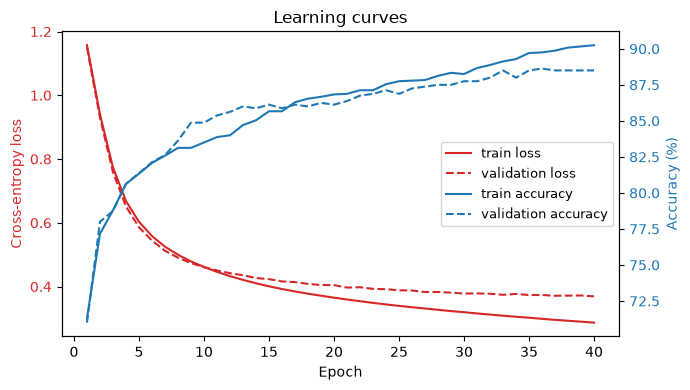

In [13]:
epochs = np.arange(1, n_epochs + 1)
fig, ax1 = plt.subplots(figsize=(7, 4))

loss_color = "tab:red"
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Cross-entropy loss", color=loss_color)
ax1.plot(epochs, history["train_loss"], color=loss_color, label="train loss")
ax1.plot(epochs, history["val_loss"], color=loss_color, linestyle="--", label="validation loss")
ax1.tick_params(axis="y", labelcolor=loss_color)

ax2 = ax1.twinx()
acc_color = "tab:blue"
ax2.set_ylabel("Accuracy (%)", color=acc_color)
ax2.plot(epochs, history["train_acc"], color=acc_color, label="train accuracy")
ax2.plot(epochs, history["val_acc"], color=acc_color, linestyle="--", label="validation accuracy")
ax2.tick_params(axis="y", labelcolor=acc_color)

lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], loc="center right", fontsize=9)
ax1.set_title("Learning curves")
fig.tight_layout()
plt.show()

## 6. Evaluate on the Test Set

The validation set guided training; the test set gives the final, unbiased score. We report the overall accuracy and the confusion matrix, which shows which classes get mixed up.

Test loss: 0.375 - test accuracy: 87.1%


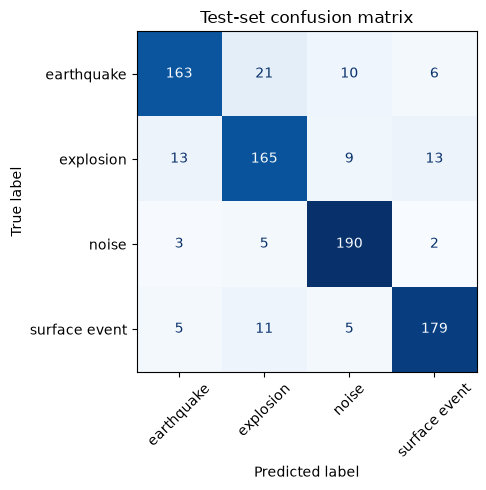

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"Test loss: {test_loss:.3f} - test accuracy: {test_acc:.1f}%")

# Predictions for the whole test set
model.eval()
with torch.no_grad():
    logits = model(torch.tensor(X_test, dtype=torch.float32).to(device))
    y_pred = logits.argmax(dim=1).cpu().numpy()

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(5.5, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
ax.set_title("Test-set confusion matrix")
fig.tight_layout()
plt.show()

Noise separates cleanly from the rest. Most confusion occurs among the seismic sources, chiefly between earthquakes and explosions, which produce similar waveforms. Compare this matrix with your Chapter 3 results on the same data: a one-hidden-layer network and a tuned random forest land in a similar range, which is common on small tabular datasets.

## Summary

You built a complete PyTorch workflow: a `Dataset` and `DataLoader` for the seismic-source features, a one-hidden-layer network, the cross-entropy loss, the Adam optimizer, and a training loop with learning curves and a held-out test evaluation. In notebook 4.2 we stack more hidden layers into a multi-layer perceptron and add regularization to control overfitting. In notebook 4.5 we tune architecture and training hyperparameters systematically instead of picking them by hand.